In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

CUTOFF_HZ  = 2.0
WINDOW     = 4

def fft_lowpass(sig, dt, cutoff=CUTOFF_HZ):
    n, mean = len(sig), sig.mean()
    F = np.fft.rfft(sig - mean)
    F[np.fft.rfftfreq(n, d=dt) > cutoff] = 0
    return np.fft.irfft(F, n=n) + mean

def moving_average_1d(data, w):
    return np.convolve(data, np.ones(w) / w, mode='valid')

# ── RGB 로드 ──────────────────────────────────────────────────────────────────
RGB_DIR = Path("/home/ftk3187/github/DPC_research/DATAFUSION/data_0422_rgb")
RGB_FILES = {
    "500W": ["HAMMER_Square_500W_1_7.csv",   "HAMMER_Square_500W_2_9.csv"],
    "600W": ["HAMMER_Square_600W_1_12.csv",  "HAMMER_Square_600W_2_13.csv"],
    "700W": ["HAMMER_Square_700W_1_10.csv",  "HAMMER_Square_700W_2_11.csv"],
}
all_data = {}
for watt, fnames in RGB_FILES.items():
    dfs = []
    for fname in fnames:
        df = pd.read_csv(RGB_DIR / fname)
        df.columns = df.columns.str.strip()
        df["time"] = df["time_value"] - 5
        dfs.append(df)
    all_data[watt] = dfs

# ── Simulation 로드 ───────────────────────────────────────────────────────────
FILE_FULL = "/home/ftk3187/github/DPC_research/DATAFUSION/merged_df_2_99_temp_depth.csv"
df_all_full = pd.read_csv(FILE_FULL, usecols=["time_index", "melt_pool_temperature",
                                               "laser_power_number", "Laser_power", "Z"])
LP_MAP  = {"600W": 91, "700W": 82}   # 500W는 extrapolation
LP_LIST = [38, 91, 82]

sim_data = {}
for watt, lp in LP_MAP.items():
    df_lp   = df_all_full[df_all_full["laser_power_number"] == lp].reset_index(drop=True)
    temp_ma = moving_average_1d(df_lp["melt_pool_temperature"].values / 2 - 273.15, WINDOW)
    time_ma = df_lp["time_index"].values[WINDOW - 1:]
    z_ma    = df_lp["Z"].values[WINDOW - 1:]
    sim_data[watt] = {"time": time_ma, "temp": temp_ma, "z": z_ma}

# 500W extrapolation
t_start  = max(df_all_full[df_all_full["laser_power_number"]==lp]["time_index"].min() for lp in LP_LIST)
t_end    = min(df_all_full[df_all_full["laser_power_number"]==lp]["time_index"].max() for lp in LP_LIST)
t_common = np.linspace(t_start, t_end, 1000)

interp_temp  = {lp: np.interp(t_common,
                    df_all_full[df_all_full["laser_power_number"]==lp]["time_index"].values[WINDOW-1:],
                    moving_average_1d(df_all_full[df_all_full["laser_power_number"]==lp]["melt_pool_temperature"].values / 2 - 273.15, WINDOW),
                    ) for lp in LP_LIST}
interp_power = {lp: np.interp(t_common,
                    df_all_full[df_all_full["laser_power_number"]==lp]["time_index"].values[WINDOW-1:],
                    df_all_full[df_all_full["laser_power_number"]==lp]["Laser_power"].values[WINDOW-1:],
                    ) for lp in LP_LIST}

temp_extrap_500 = np.array([
    np.polyval(np.polyfit([interp_power[lp][i] for lp in LP_LIST],
                          [interp_temp[lp][i]  for lp in LP_LIST], 1), 500)
    for i in range(len(t_common))
])

sim_data["500W"] = {
    "time": t_common,
    "temp": temp_extrap_500,
    "z":    np.interp(t_common, sim_data["600W"]["time"], sim_data["600W"]["z"])
}

# ── Photodiode 로드 ───────────────────────────────────────────────────────────
PD_DIR = Path("/home/ftk3187/github/DPC_research/DATAFUSION/data_0422_photodiode")
PD_FILES = {
    "500W": ["HAMMER_Square_500W_1_7_NO DELAY.csv",  "HAMMER_Square_500W_2_9_NO DELAY.csv"],
    "600W": ["HAMMER_Square_600W_1_12_NO DELAY.csv", "HAMMER_Square_600W_1_13_NO DELAY.csv"],
    "700W": ["HAMMER_Square_700W_1_10_NO DELAY.csv", "HAMMER_Square_700W_2_11_NO DELAY.csv"],
}
pd_data = {}
for watt, fnames in PD_FILES.items():
    pd_data[watt] = []
    for fname in fnames:
        df_pd = pd.read_csv(PD_DIR / fname)
        df_pd.columns = df_pd.columns.str.strip()
        time_raw = df_pd.iloc[:, 0].values - 5
        raw      = df_pd.iloc[:, 3].values
        first_valid = max(0,            np.argmax(raw >= 1120))
        last_valid  = min(len(raw) - 1, len(raw) - 1 - np.argmax(raw[::-1] >= 1120))
        time_trim = time_raw[first_valid : last_valid + 1]
        raw_trim  = raw[first_valid : last_valid + 1]
        dt_pd  = np.median(np.diff(time_trim))
        temp_f = fft_lowpass(raw_trim, dt_pd)
        pd_data[watt].append((time_trim, temp_f))

print("로드 완료")
print(f"sim_data keys: {list(sim_data.keys())}")
for watt in ["500W", "600W", "700W"]:
    print(f"{watt} sim z range: {sim_data[watt]['z'].min():.2f} ~ {sim_data[watt]['z'].max():.2f}")

로드 완료
sim_data keys: ['600W', '700W', '500W']
500W sim z range: 0.75 ~ 7.50
600W sim z range: 0.75 ~ 7.50
700W sim z range: 0.75 ~ 7.50


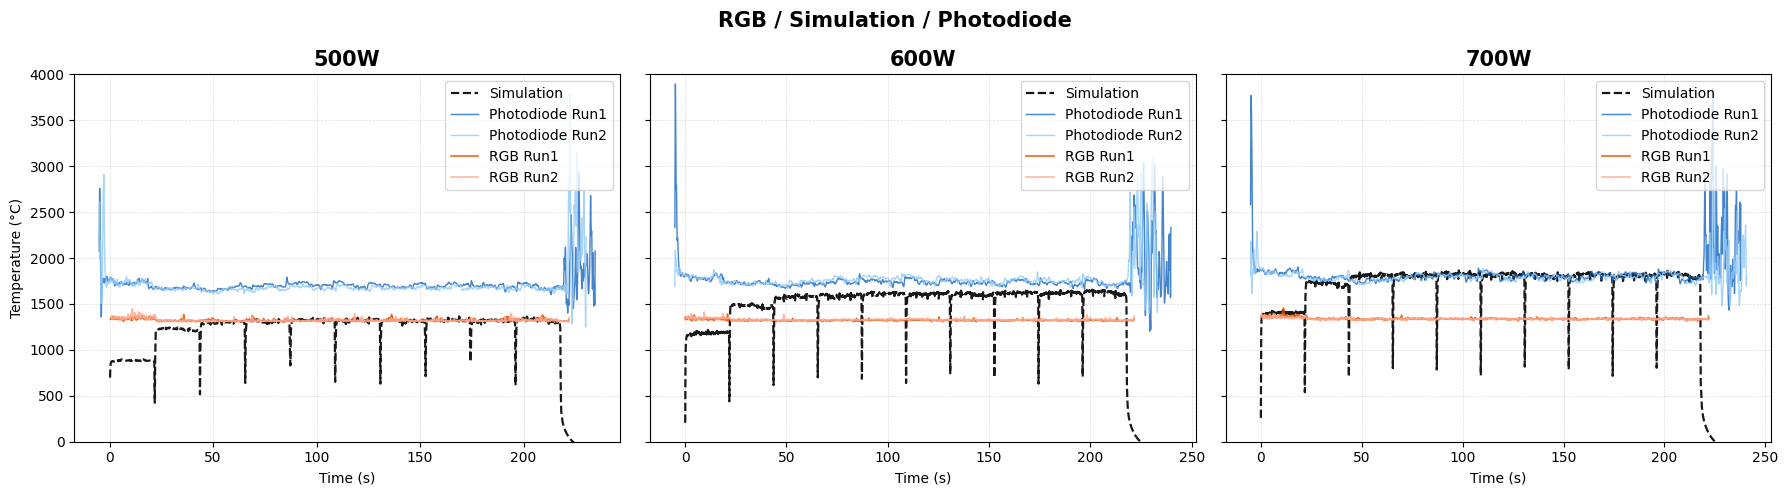

In [2]:
WATT_LIST = ["500W", "600W", "700W"]

# ── 색상 ──────────────────────────────────────────────────────────────────────
# 파워별 구분 없이 센서 종류별로 통일
SIM_COLOR = {"color": "black",      "linestyle": "--", "linewidth": 1.6}
PD_COLOR  = [{"color": "#1565C0", "linestyle": "-", "linewidth": 1.0},   # Run1 진파랑
             {"color": "#90CAF9", "linestyle": "-", "linewidth": 1.0}]   # Run2 연파랑
RGB_COLOR = [{"color": "#E65100", "linestyle": "-", "linewidth": 1.2},   # Run1 진주황
             {"color": "#FFAB91", "linestyle": "-", "linewidth": 1.2}]   # Run2 연주황

# ── 플롯 ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f"RGB / Simulation / Photodiode",
             fontsize=15, fontweight="bold")

for ax, watt in zip(axes, WATT_LIST):

    # 1) Simulation
    ax.plot(sim_data[watt]["time"], sim_data[watt]["temp"],
            **SIM_COLOR, alpha=0.9, label="Simulation")

    # 2) Photodiode
    for run_idx, (t_pd, temp_pd) in enumerate(pd_data[watt]):
        ax.plot(t_pd, temp_pd, **PD_COLOR[run_idx], alpha=0.8,
                label=f"Photodiode Run{run_idx+1}")

    # 3) RGB
    for run_idx, (df, c) in enumerate(zip(all_data[watt], RGB_COLOR)):
        sig   = df["max_temp"].values
        dt    = df["time"].diff().median()
        sig_f = fft_lowpass(sig, dt)
        ax.plot(df["time"].values[:len(sig_f)], sig_f,
                **c, alpha=0.85, label=f"RGB Run{run_idx+1}")

    ax.set_title(watt, fontsize=15, fontweight="bold")
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylim(0, 4000)
    # ax.set_xlim(-5,222)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
    ax.legend(fontsize=10, loc="upper right")

axes[0].set_ylabel("Temperature (°C)", fontsize=10)
plt.tight_layout()
plt.show()

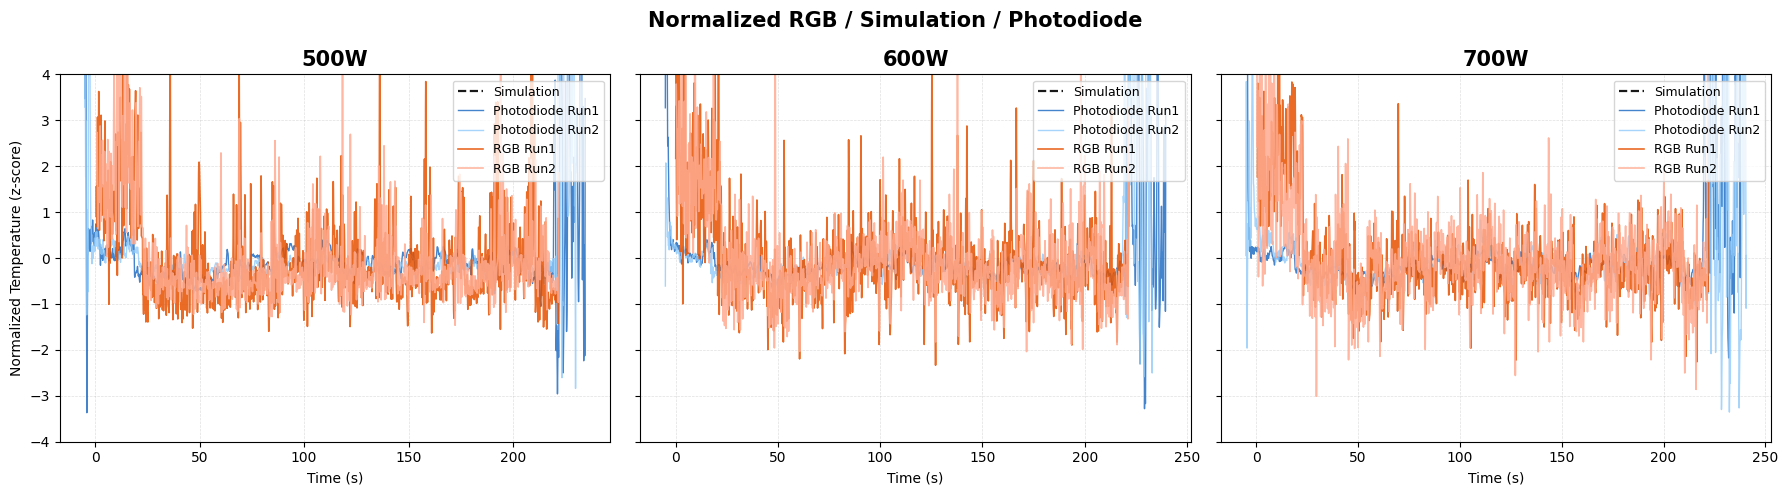

In [7]:
# ── Z-score normalization 함수 ────────────────────────────────────────────────
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

# ── Normalize + Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle("Normalized RGB / Simulation / Photodiode",
             fontsize=15, fontweight="bold")

for ax, watt in zip(axes, WATT_LIST):

    # ─────────────────────────────────────────────────────────────
    # 1) Simulation
    # ─────────────────────────────────────────────────────────────
    sim_temp_z = zscore(sim_data[watt]["temp"])

    ax.plot(sim_data[watt]["time"],
            sim_temp_z,
            **SIM_COLOR,
            alpha=0.9,
            label="Simulation")

    # ─────────────────────────────────────────────────────────────
    # 2) Photodiode
    # ─────────────────────────────────────────────────────────────
    for run_idx, (t_pd, temp_pd) in enumerate(pd_data[watt]):

        temp_pd_z = zscore(temp_pd)

        ax.plot(t_pd,
                temp_pd_z,
                **PD_COLOR[run_idx],
                alpha=0.8,
                label=f"Photodiode Run{run_idx+1}")

    # ─────────────────────────────────────────────────────────────
    # 3) RGB
    # ─────────────────────────────────────────────────────────────
    for run_idx, (df, c) in enumerate(zip(all_data[watt], RGB_COLOR)):

        sig = df["max_temp"].values

        dt = df["time"].diff().median()

        sig_f = fft_lowpass(sig, dt)

        sig_rgb_z = zscore(sig_f)

        ax.plot(df["time"].values[:len(sig_rgb_z)],
                sig_rgb_z,
                **c,
                alpha=0.85,
                label=f"RGB Run{run_idx+1}")

    # ─────────────────────────────────────────────────────────────
    # Plot formatting
    # ─────────────────────────────────────────────────────────────
    ax.set_title(watt, fontsize=15, fontweight="bold")

    ax.set_xlabel("Time (s)", fontsize=10)

    ax.set_ylim(-4, 4)

    # ax.set_xlim(-5, 222)

    ax.grid(True,
            linestyle="--",
            linewidth=0.5,
            alpha=0.4)

    ax.legend(fontsize=9, loc="upper right")

axes[0].set_ylabel("Normalized Temperature (z-score)", fontsize=10)

plt.tight_layout()

plt.show()


500W
500W Simulation           | n=  1000 | mean= 1219.650 | std=  247.014 | min=  -17.806 | max= 1364.663
500W Simulation time | min=0.000, max=224.948
500W Simulation z+offset | min=0.990, max=6.587
500W PD Run1              | n=4791660 | mean= 1711.959 | std=  104.950 | min= 1358.441 | max= 2928.753
500W PD Run2              | n=4703714 | mean= 1702.616 | std=  160.140 | min= 1247.905 | max= 3776.053
500W RGB Run1             | n= 43443 | mean= 1323.327 | std=   11.761 | min= 1304.124 | max= 1385.226
500W RGB Run2             | n= 43441 | mean= 1322.485 | std=   16.417 | min= 1298.448 | max= 1446.276

600W
600W Simulation           | n=  6292 | mean= 1495.339 | std=  287.374 | min=   -4.753 | max= 1656.007
600W Simulation time | min=0.107, max=224.948
600W Simulation z+offset | min=0.780, max=6.559
600W PD Run1              | n=4892893 | mean= 1768.781 | std=  172.424 | min= 1203.077 | max= 3895.152
600W PD Run2              | n=4763275 | mean= 1780.287 | std=  148.292 | min= 1396.

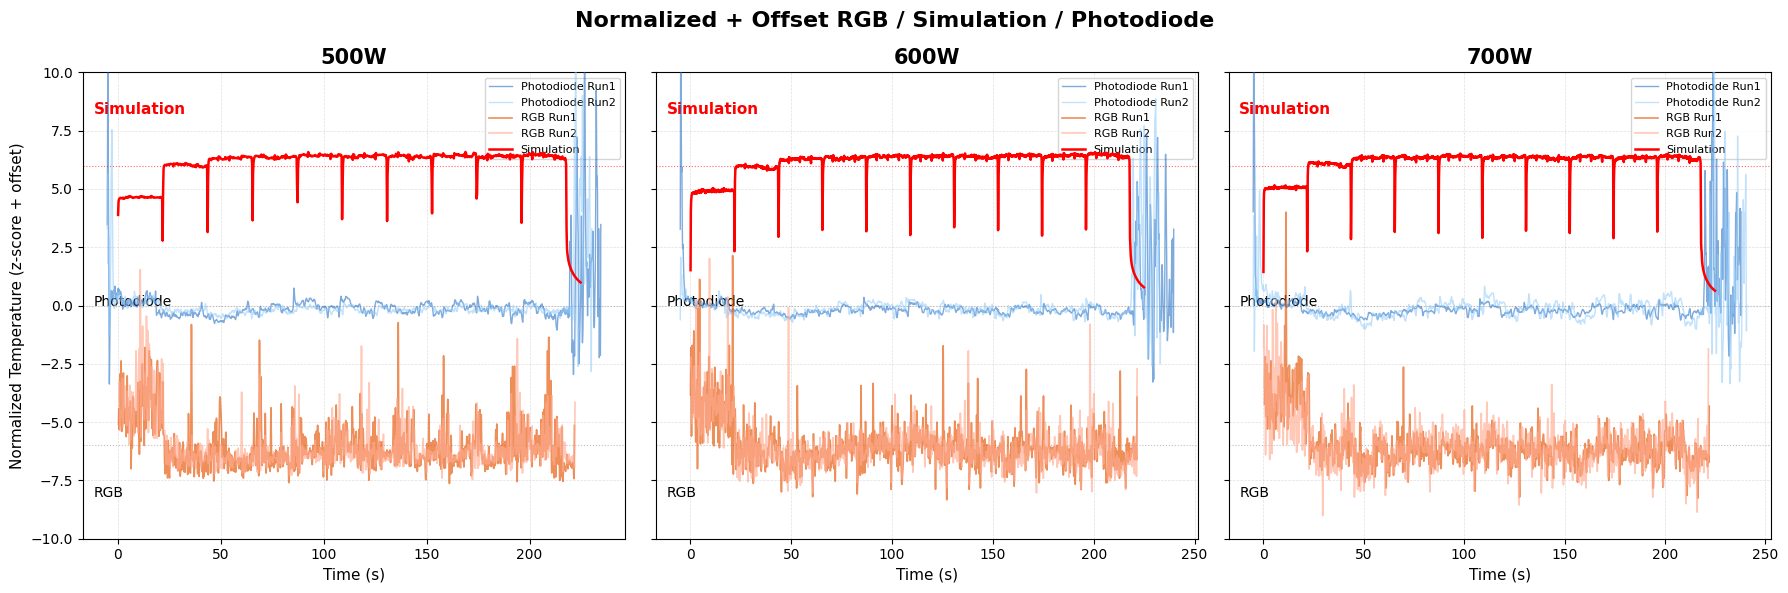

In [15]:
# ── Safe Z-score normalization 함수 ───────────────────────────────────────────
def zscore_safe(x, name="signal"):
    x = np.asarray(x, dtype=float)

    mean = np.nanmean(x)
    std  = np.nanstd(x)

    print(f"{name:25s} | n={len(x):6d} | mean={mean:9.3f} | std={std:9.3f} | "
          f"min={np.nanmin(x):9.3f} | max={np.nanmax(x):9.3f}")

    if np.isnan(std) or std < 1e-12:
        print(f"WARNING: {name} std is zero or NaN")
        return np.zeros_like(x)

    return (x - mean) / std


# ── Offset 설정 ───────────────────────────────────────────────────────────────
SIM_OFFSET = 6
PD_OFFSET  = 0
RGB_OFFSET = -6

# simulation 잘 보이게 별도 style
SIM_COLOR_DEBUG = {
    "color": "red",
    "linestyle": "-",
    "linewidth": 1.8,
    "zorder": 100
}

# ── Normalize + Offset Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

fig.suptitle("Normalized + Offset RGB / Simulation / Photodiode",
             fontsize=16,
             fontweight="bold")

for ax, watt in zip(axes, WATT_LIST):

    print("\n" + "="*80)
    print(f"{watt}")
    print("="*80)

    # ========================================================================
    # 1) Simulation 계산
    # ========================================================================
    sim_time = np.asarray(sim_data[watt]["time"], dtype=float)
    sim_temp = np.asarray(sim_data[watt]["temp"], dtype=float)

    sim_temp_z = zscore_safe(sim_temp, f"{watt} Simulation")

    print(f"{watt} Simulation time | "
          f"min={np.nanmin(sim_time):.3f}, max={np.nanmax(sim_time):.3f}")

    print(f"{watt} Simulation z+offset | "
          f"min={np.nanmin(sim_temp_z + SIM_OFFSET):.3f}, "
          f"max={np.nanmax(sim_temp_z + SIM_OFFSET):.3f}")

    # ========================================================================
    # 2) Photodiode 먼저 plot
    # ========================================================================
    for run_idx, (t_pd, temp_pd) in enumerate(pd_data[watt]):

        t_pd = np.asarray(t_pd, dtype=float)
        temp_pd = np.asarray(temp_pd, dtype=float)

        temp_pd_z = zscore_safe(temp_pd, f"{watt} PD Run{run_idx+1}")

        ax.plot(t_pd,
                temp_pd_z + PD_OFFSET,
                **PD_COLOR[run_idx],
                alpha=0.55,
                zorder=10,
                label=f"Photodiode Run{run_idx+1}")

    # ========================================================================
    # 3) RGB plot
    # ========================================================================
    for run_idx, (df, c) in enumerate(zip(all_data[watt], RGB_COLOR)):

        t_rgb = df["time"].values
        sig = df["max_temp"].values

        dt = df["time"].diff().median()
        sig_f = fft_lowpass(sig, dt)

        t_rgb = t_rgb[:len(sig_f)]

        sig_rgb_z = zscore_safe(sig_f, f"{watt} RGB Run{run_idx+1}")

        ax.plot(t_rgb,
                sig_rgb_z + RGB_OFFSET,
                **c,
                alpha=0.65,
                zorder=20,
                label=f"RGB Run{run_idx+1}")

    # ========================================================================
    # 4) Simulation을 마지막에 다시 plot
    # ========================================================================
    ax.plot(sim_time,
            sim_temp_z + SIM_OFFSET,
            **SIM_COLOR_DEBUG,
            alpha=1,
            label="Simulation")

    # # simulation point도 찍어서 존재 여부 확인
    # ax.scatter(sim_time[::max(1, len(sim_time)//100)],
    #            (sim_temp_z + SIM_OFFSET)[::max(1, len(sim_time)//100)],
    #            color="red",
    #            s=10,
    #            zorder=101)

    # ========================================================================
    # Formatting
    # ========================================================================
    ax.set_title(watt, fontsize=15, fontweight="bold")
    ax.set_xlabel("Time (s)", fontsize=11)

    ax.set_ylim(-10, 10)

    # 필요하면 time range 강제
    # ax.set_xlim(-5, 222)

    ax.grid(True,
            linestyle="--",
            linewidth=0.5,
            alpha=0.4)

    ax.axhline(SIM_OFFSET, color="red", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.axhline(PD_OFFSET,  color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.axhline(RGB_OFFSET, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

    ax.text(0.02, 0.91, "Simulation", color="red",
            transform=ax.transAxes, fontsize=11, fontweight="bold")

    ax.text(0.02, 0.50, "Photodiode",
            transform=ax.transAxes, fontsize=10)

    ax.text(0.02, 0.09, "RGB",
            transform=ax.transAxes, fontsize=10)

    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Normalized Temperature (z-score + offset)",
                   fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
from scipy.interpolate import interp1d

# ── Common time axis ─────────────────────────────────────────────────────────
t_min = 0
t_max = 220

dt_common = 0.1

t_common = np.arange(t_min, t_max, dt_common)

def interp_signal(t_src, sig_src, t_new):

    f = interp1d(t_src,
                 sig_src,
                 bounds_error=False,
                 fill_value="extrapolate")

    return f(t_new)

In [18]:
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate

# ======================================================================
# 선택할 power
# ======================================================================
watt = "700W"

# ======================================================================
# Simulation
# ======================================================================
sim_time = sim_data[watt]["time"]
sim_temp = zscore_safe(sim_data[watt]["temp"])

sim_interp = interp_signal(sim_time,
                           sim_temp,
                           t_common)

# ======================================================================
# Photodiode Run1
# ======================================================================
t_pd, temp_pd = pd_data[watt][0]

temp_pd_z = zscore_safe(temp_pd)

pd_interp = interp_signal(t_pd,
                          temp_pd_z,
                          t_common)

# ======================================================================
# RGB Run1
# ======================================================================
df_rgb = all_data[watt][0]

sig_rgb = df_rgb["max_temp"].values

dt_rgb = df_rgb["time"].diff().median()

sig_rgb_f = fft_lowpass(sig_rgb, dt_rgb)

sig_rgb_z = zscore_safe(sig_rgb_f)

rgb_interp = interp_signal(df_rgb["time"].values[:len(sig_rgb_z)],
                           sig_rgb_z,
                           t_common)

# ======================================================================
# 1) Pearson correlation
# ======================================================================
r_sim_pd, p_sim_pd = pearsonr(sim_interp, pd_interp)

r_sim_rgb, p_sim_rgb = pearsonr(sim_interp, rgb_interp)

# ======================================================================
# 2) Spearman correlation
# ======================================================================
rho_sim_pd, _ = spearmanr(sim_interp, pd_interp)

rho_sim_rgb, _ = spearmanr(sim_interp, rgb_interp)

# ======================================================================
# 결과 출력
# ======================================================================
print("\n================ Pearson =================")
print(f"Sim vs PD   : r = {r_sim_pd:.4f}, p = {p_sim_pd:.4e}")
print(f"Sim vs RGB  : r = {r_sim_rgb:.4f}, p = {p_sim_rgb:.4e}")

print("\n================ Spearman ================")
print(f"Sim vs PD   : rho = {rho_sim_pd:.4f}")
print(f"Sim vs RGB  : rho = {rho_sim_rgb:.4f}")

signal                    | n=  6292 | mean= 1701.582 | std=  316.301 | min=    4.606 | max= 1864.984
signal                    | n=4856809 | mean= 1835.540 | std=  185.296 | min= 1432.527 | max= 3846.167
signal                    | n= 43447 | mean= 1339.954 | std=   11.632 | min= 1313.653 | max= 1456.285

================ Pearson =================
Sim vs PD   : r = -0.3640, p = 6.9332e-70
Sim vs RGB  : r = -0.2883, p = 2.3199e-43

================ Spearman ================
Sim vs PD   : rho = -0.0484
Sim vs RGB  : rho = -0.2076


In [19]:
# ======================================================================
# Derivative
# ======================================================================
d_sim = np.gradient(sim_interp, dt_common)

d_pd  = np.gradient(pd_interp, dt_common)

d_rgb = np.gradient(rgb_interp, dt_common)

# ======================================================================
# Derivative Pearson
# ======================================================================
r_d_sim_pd, _ = pearsonr(d_sim, d_pd)

r_d_sim_rgb, _ = pearsonr(d_sim, d_rgb)

print("\n================ Derivative Correlation =================")
print(f"dSim vs dPD   : r = {r_d_sim_pd:.4f}")
print(f"dSim vs dRGB  : r = {r_d_sim_rgb:.4f}")


================ Derivative Correlation =================
dSim vs dPD   : r = 0.0189
dSim vs dRGB  : r = 0.1198


In [20]:
lags = np.arange(-200, 201)

corrs = []

for lag in lags:

    if lag < 0:
        x = sim_interp[:lag]
        y = pd_interp[-lag:]

    elif lag > 0:
        x = sim_interp[lag:]
        y = pd_interp[:-lag]

    else:
        x = sim_interp
        y = pd_interp

    corrs.append(np.corrcoef(x, y)[0,1])

corrs = np.array(corrs)

best_idx = np.argmax(corrs)

best_lag = lags[best_idx] * dt_common

best_corr = corrs[best_idx]

print(f"\nBest lag = {best_lag:.2f} sec")
print(f"Best correlation = {best_corr:.4f}")


Best lag = -19.50 sec
Best correlation = 0.1514


signal                    | n=  6292 | mean= 1701.582 | std=  316.301 | min=    4.606 | max= 1864.984
Simulation dt = 0.03574 sec
signal                    | n=4856809 | mean= 1835.540 | std=  185.296 | min= 1432.527 | max= 3846.167
Photodiode dt = 0.00005 sec
signal                    | n= 43447 | mean= 1339.954 | std=   11.632 | min= 1313.653 | max= 1456.285
RGB dt = 0.00500 sec


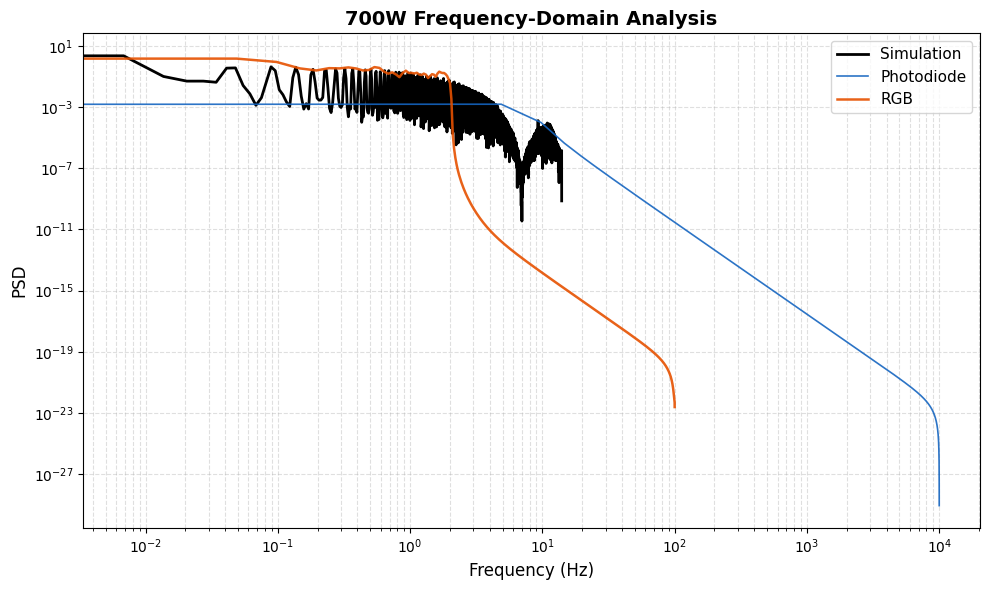

In [21]:
from scipy.signal import welch

# ======================================================================
# PSD helper
# ======================================================================
def compute_psd(signal, dt):

    fs = 1 / dt

    freq, psd = welch(signal,
                      fs=fs,
                      nperseg=min(4096, len(signal)))

    return freq, psd


# ======================================================================
# 선택할 power
# ======================================================================
watt = "700W"

# ======================================================================
# Simulation
# ======================================================================
sim_time = sim_data[watt]["time"]

sim_temp = zscore_safe(sim_data[watt]["temp"])

dt_sim = np.median(np.diff(sim_time))

freq_sim, psd_sim = compute_psd(sim_temp, dt_sim)

print(f"Simulation dt = {dt_sim:.5f} sec")


# ======================================================================
# Photodiode Run1
# ======================================================================
t_pd, temp_pd = pd_data[watt][0]

temp_pd_z = zscore_safe(temp_pd)

dt_pd = np.median(np.diff(t_pd))

freq_pd, psd_pd = compute_psd(temp_pd_z, dt_pd)

print(f"Photodiode dt = {dt_pd:.5f} sec")


# ======================================================================
# RGB Run1
# ======================================================================
df_rgb = all_data[watt][0]

sig_rgb = df_rgb["max_temp"].values

dt_rgb = df_rgb["time"].diff().median()

sig_rgb_f = fft_lowpass(sig_rgb, dt_rgb)

sig_rgb_z = zscore_safe(sig_rgb_f)

freq_rgb, psd_rgb = compute_psd(sig_rgb_z, dt_rgb)

print(f"RGB dt = {dt_rgb:.5f} sec")


# ======================================================================
# PSD Plot
# ======================================================================
plt.figure(figsize=(10, 6))

plt.loglog(freq_sim,
           psd_sim,
           color="black",
           linewidth=2,
           label="Simulation")

plt.loglog(freq_pd,
           psd_pd,
           color="#1565C0",
           linewidth=1.2,
           alpha=0.9,
           label="Photodiode")

plt.loglog(freq_rgb,
           psd_rgb,
           color="#E65100",
           linewidth=1.8,
           alpha=0.9,
           label="RGB")

plt.xlabel("Frequency (Hz)", fontsize=12)

plt.ylabel("PSD", fontsize=12)

plt.title(f"{watt} Frequency-Domain Analysis",
          fontsize=14,
          fontweight="bold")

plt.grid(True,
         which="both",
         linestyle="--",
         alpha=0.4)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

Common valid time range: 0.63 ~ 219.99 s
N valid = 21937
Common fs = 100.0 Hz


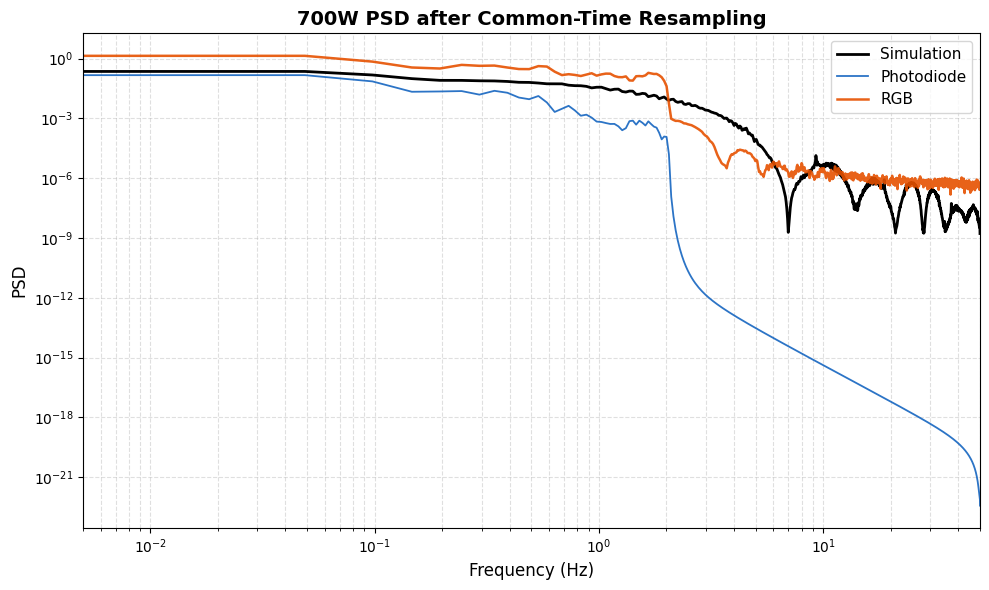

In [22]:
from scipy.signal import welch
from scipy.interpolate import interp1d

# ======================================================================
# helper
# ======================================================================
def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x)

def interp_to_common_time(t, y, t_common):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    idx = np.argsort(t)
    t = t[idx]
    y = y[idx]

    f = interp1d(t, y, bounds_error=False, fill_value=np.nan)
    return f(t_common)

def compute_psd(y, fs):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    freq, psd = welch(
        y,
        fs=fs,
        nperseg=min(2048, len(y)),
        detrend="constant"
    )

    return freq, psd


# ======================================================================
# settings
# ======================================================================
watt = "700W"

t_min = 0
t_max = 220
dt_common = 0.01          # 100 Hz sampling
fs_common = 1 / dt_common

t_common = np.arange(t_min, t_max, dt_common)


# ======================================================================
# Simulation
# ======================================================================
sim_time = sim_data[watt]["time"]
sim_temp = zscore_safe(sim_data[watt]["temp"])

sim_common = interp_to_common_time(sim_time, sim_temp, t_common)


# ======================================================================
# Photodiode Run1
# ======================================================================
t_pd, temp_pd = pd_data[watt][0]
temp_pd_z = zscore_safe(temp_pd)

pd_common = interp_to_common_time(t_pd, temp_pd_z, t_common)


# ======================================================================
# RGB Run1
# ======================================================================
df_rgb = all_data[watt][0]

sig_rgb = df_rgb["max_temp"].values
dt_rgb = df_rgb["time"].diff().median()

sig_rgb_f = fft_lowpass(sig_rgb, dt_rgb)
sig_rgb_z = zscore_safe(sig_rgb_f)

rgb_common = interp_to_common_time(
    df_rgb["time"].values[:len(sig_rgb_z)],
    sig_rgb_z,
    t_common
)


# ======================================================================
# valid common range만 사용
# ======================================================================
valid = (
    np.isfinite(sim_common) &
    np.isfinite(pd_common) &
    np.isfinite(rgb_common)
)

t_valid = t_common[valid]

sim_valid = sim_common[valid]
pd_valid  = pd_common[valid]
rgb_valid = rgb_common[valid]

print(f"Common valid time range: {t_valid.min():.2f} ~ {t_valid.max():.2f} s")
print(f"N valid = {len(t_valid)}")
print(f"Common fs = {fs_common:.1f} Hz")


# ======================================================================
# PSD
# ======================================================================
freq_sim, psd_sim = compute_psd(sim_valid, fs_common)
freq_pd,  psd_pd  = compute_psd(pd_valid,  fs_common)
freq_rgb, psd_rgb = compute_psd(rgb_valid, fs_common)


# ======================================================================
# Plot
# ======================================================================
plt.figure(figsize=(10, 6))

plt.loglog(freq_sim, psd_sim,
           color="black",
           linewidth=2,
           label="Simulation")

plt.loglog(freq_pd, psd_pd,
           color="#1565C0",
           linewidth=1.3,
           alpha=0.9,
           label="Photodiode")

plt.loglog(freq_rgb, psd_rgb,
           color="#E65100",
           linewidth=1.8,
           alpha=0.9,
           label="RGB")

plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("PSD", fontsize=12)

plt.title(f"{watt} PSD after Common-Time Resampling",
          fontsize=14,
          fontweight="bold")

plt.xlim(0.005, fs_common / 2)

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [3]:
for watt in ["500W", "600W", "700W"]:
    print(f"\n{'='*30} {watt} {'='*30}")
    print(f"  Sim:  {sim_data[watt]['time'].min():.2f} ~ {sim_data[watt]['time'].max():.2f}s")
    for i, (t, _) in enumerate(pd_data[watt]):
        print(f"  PD  Run{i+1}: {t.min():.2f} ~ {t.max():.2f}s")
    for i, df in enumerate(all_data[watt]):
        print(f"  RGB Run{i+1}: {df['time'].min():.2f} ~ {df['time'].max():.2f}s")


============================== 500W ==============================
  Sim:  0.00 ~ 224.95s
  PD  Run1: -5.00 ~ 234.58s
  PD  Run2: -5.00 ~ 230.19s
  RGB Run1: 0.45 ~ 221.78s
  RGB Run2: 0.76 ~ 222.06s

============================== 600W ==============================
  Sim:  0.11 ~ 224.95s
  PD  Run1: -5.00 ~ 239.64s
  PD  Run2: -5.00 ~ 233.16s
  RGB Run1: 0.08 ~ 221.44s
  RGB Run2: 0.18 ~ 221.50s

============================== 700W ==============================
  Sim:  0.11 ~ 224.95s
  PD  Run1: -5.00 ~ 237.84s
  PD  Run2: -5.00 ~ 240.64s
  RGB Run1: 0.63 ~ 222.02s
  RGB Run2: 0.23 ~ 221.61s


In [4]:
# ── Z 레이어 매핑 함수 ────────────────────────────────────────────────────────
def assign_layer(z_vals):
    z_rounded = np.round(z_vals / 0.75) * 0.75
    layer = np.round(z_rounded / 0.75).astype(float)
    layer[layer == 0] = np.nan
    layer[layer > 10] = np.nan
    return layer

df_ref = df_all_full[df_all_full["laser_power_number"] == 91].reset_index(drop=True)
sim_time_ref = df_ref["time_index"].values
sim_z_ref    = df_ref["Z"].values

from scipy.interpolate import interp1d
z_interp = interp1d(sim_time_ref, sim_z_ref, kind='linear',
                    bounds_error=False, fill_value=np.nan)

# ── Simulation 통계 ───────────────────────────────────────────────────────────
sim_stats = {}
for watt in ["500W", "600W", "700W"]:
    layers = assign_layer(sim_data[watt]["z"])
    temp   = sim_data[watt]["temp"]
    stats  = {}
    for l in range(1, 11):
        mask = layers == l
        if mask.sum() > 0:
            stats[l] = {"mean": np.nanmean(temp[mask]), "std": np.nanstd(temp[mask])}
        else:
            stats[l] = {"mean": np.nan, "std": np.nan}
    sim_stats[watt] = stats

# ── RGB 통계 ─────────────────────────────────────────────────────────────────
rgb_stats = {}
for watt, dfs in all_data.items():
    all_temp, all_layer = [], []
    for df in dfs:
        sig   = df["max_temp"].values
        dt    = df["time"].diff().median()
        sig_f = fft_lowpass(sig, dt)
        time  = df["time"].values[:len(sig_f)]
        z_interped = z_interp(time)
        layers = assign_layer(z_interped)
        all_temp.append(sig_f)
        all_layer.append(layers)

    all_temp  = np.concatenate(all_temp)
    all_layer = np.concatenate(all_layer)
    stats = {}
    for l in range(1, 11):
        mask = all_layer == l
        if mask.sum() > 0:
            stats[l] = {"mean": np.nanmean(all_temp[mask]), "std": np.nanstd(all_temp[mask])}
        else:
            stats[l] = {"mean": np.nan, "std": np.nan}
    rgb_stats[watt] = stats

# ── Photodiode 통계 ───────────────────────────────────────────────────────────
pd_stats = {}
for watt, runs in pd_data.items():
    all_temp, all_layer = [], []
    for time_trim, temp_f in runs:
        z_interped = z_interp(time_trim)
        layers = assign_layer(z_interped)
        all_temp.append(temp_f)
        all_layer.append(layers)

    all_temp  = np.concatenate(all_temp)
    all_layer = np.concatenate(all_layer)
    stats = {}
    for l in range(1, 11):
        mask = all_layer == l
        if mask.sum() > 0:
            stats[l] = {"mean": np.nanmean(all_temp[mask]), "std": np.nanstd(all_temp[mask])}
        else:
            stats[l] = {"mean": np.nan, "std": np.nan}
    pd_stats[watt] = stats

# ── 결과 출력 ─────────────────────────────────────────────────────────────────
for watt in ["500W", "600W", "700W"]:
    print(f"\n{'='*50} {watt} {'='*50}")
    print(f"{'Layer':>6} | {'Sim mean':>10} {'Sim std':>8} | {'PD mean':>10} {'PD std':>8} | {'RGB mean':>10} {'RGB std':>8}")
    print("-"*70)
    for l in range(1, 11):
        s = sim_stats[watt][l]
        p = pd_stats[watt][l]
        r = rgb_stats[watt][l]
        print(f"{l:>6} | {s['mean']:>10.1f} {s['std']:>8.1f} | {p['mean']:>10.1f} {p['std']:>8.1f} | {r['mean']:>10.1f} {r['std']:>8.1f}")


================================================== 500W ==================================================
 Layer |   Sim mean  Sim std |    PD mean   PD std |   RGB mean  RGB std
----------------------------------------------------------------------
     1 |      881.0     20.3 |     1729.3     27.1 |     1350.2     17.9
     2 |     1213.2     86.8 |     1670.2     12.3 |     1317.4      9.7
     3 |     1289.0     83.4 |     1656.8     22.6 |     1315.9      7.6
     4 |     1297.4     77.3 |     1681.4     25.9 |     1318.9     10.7
     5 |     1320.7     53.3 |     1696.6     24.5 |     1320.7      8.2
     6 |     1308.9     76.3 |     1693.3     26.9 |     1321.1      9.7
     7 |     1303.5     75.7 |     1686.2     19.4 |     1321.1     10.3
     8 |     1314.7     79.1 |     1688.4     22.5 |     1319.8      8.4
     9 |     1311.7     43.6 |     1684.6     19.9 |     1322.0     12.5
    10 |     1019.1    525.5 |     1725.8    236.3 |     1322.2     10.7

=================

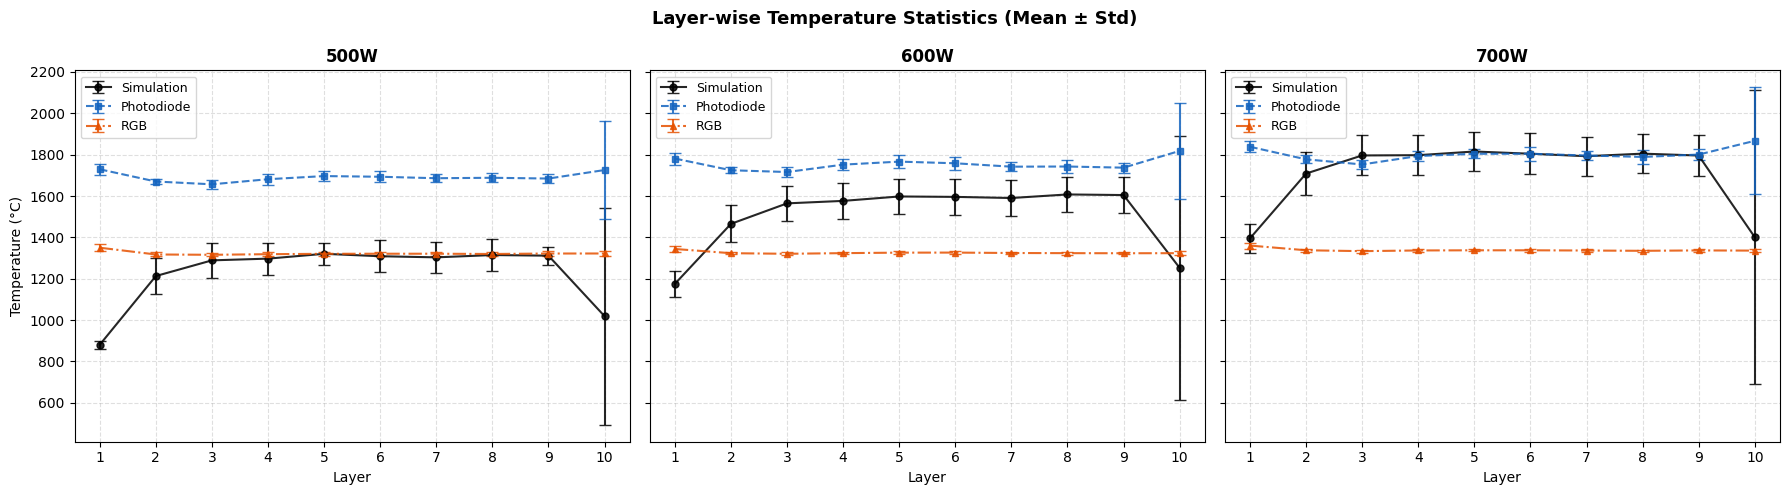

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Layer-wise Temperature Statistics (Mean ± Std)", fontsize=13, fontweight="bold")

layers = list(range(1, 11))

PLOT_STYLE = {
    "Simulation": {"color": "black",   "marker": "o", "linestyle": "-"},
    "Photodiode": {"color": "#1565C0", "marker": "s", "linestyle": "--"},
    "RGB":        {"color": "#E65100", "marker": "^", "linestyle": "-."},
}

for ax, watt in zip(axes, ["500W", "600W", "700W"]):
    for label, stats in [("Simulation", sim_stats[watt]),
                         ("Photodiode", pd_stats[watt]),
                         ("RGB",        rgb_stats[watt])]:
        means = [stats[l]["mean"] for l in layers]
        stds  = [stats[l]["std"]  for l in layers]
        s = PLOT_STYLE[label]
        ax.errorbar(layers, means, yerr=stds,
                    color=s["color"], marker=s["marker"], linestyle=s["linestyle"],
                    linewidth=1.5, markersize=5, capsize=4, alpha=0.85,
                    label=label)

    ax.set_title(watt, fontsize=12, fontweight="bold")
    ax.set_xlabel("Layer", fontsize=10)
    ax.set_xticks(layers)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Temperature (°C)", fontsize=10)
plt.tight_layout()
plt.show()

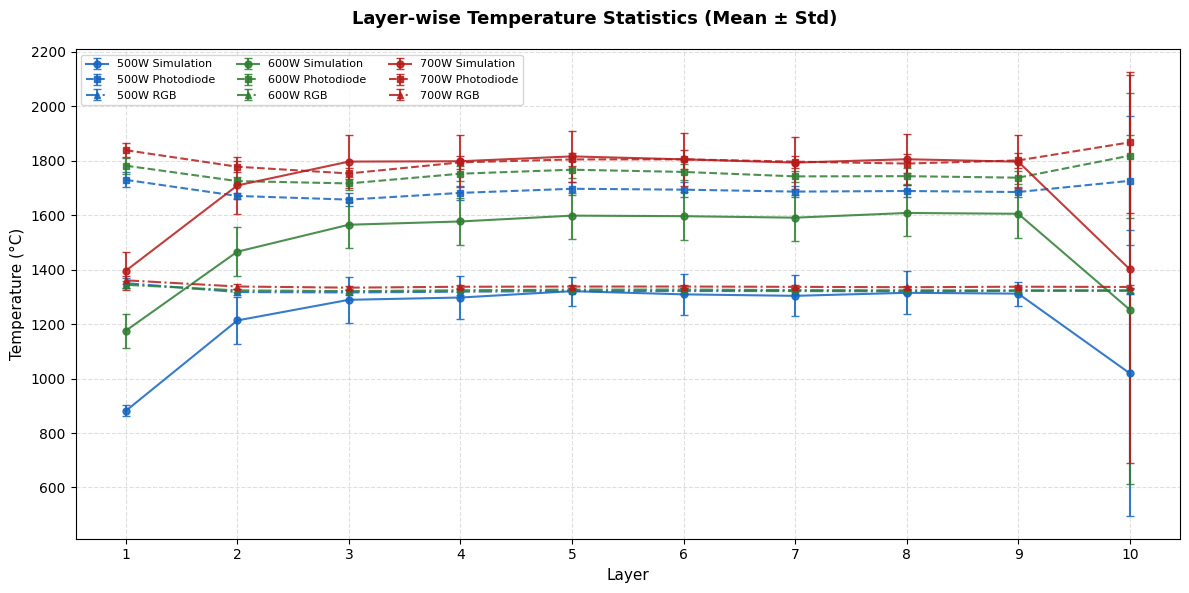

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Layer-wise Temperature Statistics (Mean ± Std)", fontsize=13, fontweight="bold")

layers = list(range(1, 11))

WATT_COLOR = {
    "500W": "#1565C0",
    "600W": "#2E7D32",
    "700W": "#B71C1C",
}
SENSOR_STYLE = {
    "Simulation": {"linestyle": "-",  "marker": "o"},
    "Photodiode": {"linestyle": "--", "marker": "s"},
    "RGB":        {"linestyle": "-.", "marker": "^"},
}

for watt in ["500W", "600W", "700W"]:
    color = WATT_COLOR[watt]
    for label, stats in [("Simulation", sim_stats[watt]),
                         ("Photodiode", pd_stats[watt]),
                         ("RGB",        rgb_stats[watt])]:
        means = [stats[l]["mean"] for l in layers]
        stds  = [stats[l]["std"]  for l in layers]
        s = SENSOR_STYLE[label]
        ax.errorbar(layers, means, yerr=stds,
                    color=color, marker=s["marker"], linestyle=s["linestyle"],
                    linewidth=1.5, markersize=5, capsize=3, alpha=0.85,
                    label=f"{watt} {label}")

ax.set_xlabel("Layer", fontsize=11)
ax.set_ylabel("Temperature (°C)", fontsize=11)
ax.set_xticks(layers)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=8, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()